## Week 1 - Análisis Exploratorio de Datos

### Introducción al Análisis Exploratorio (EDA)

Marco sistemático de EDA

Fase 1: Preparación y Contexto

    ¿Cuál es la fuente de los datos? ¿Son confiables?
    ¿Qué preguntas de negocio motivan este análisis?
    ¿Qué variables están disponibles? ¿Qué tipos de datos?
    ¿Existen restricciones temporales, geográficas o demográficas?

Fase 2: Inspección Inicial

    Dimensiones del dataset (filas, columnas)
    Tipos de datos y valores faltantes
    Estadísticos básicos por variable
    Identificación de datos problemáticos

Fase 3: Análisis Univariado

    Distribución de cada variable individual
    Identificación de outliers y anomalías
    Transformaciones necesarias (log, normalización)

Fase 4: Análisis Bivariado/Multivariado

    Relaciones entre variables importantes
    Patrones de correlación y dependencia
    Segmentación natural de los datos

Fase 5: Síntesis e Insights

    ¿Qué patrones emergen consistentemente?
    ¿Qué anomalías requieren explicación?
    ¿Qué hipótesis nuevas se generan?
    ¿Qué acciones concretas sugieren los datos?


EDA en Pandas

1. Configuración del Entorno de Análisis

```
# Importaciones estándar para EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('default')  # Estilo de gráficos
pd.set_option('display.max_columns', None)  # Mostrar todas las columnas
pd.set_option('display.width', None)  # Ancho completo
```
2. Inspección Inicial del Dataset
```
# Carga de datos
df = pd.read_csv('datos_ventas.csv')

# Dimensiones básicas
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
print(f"\nColumnas: {list(df.columns)}")

# Primeras filas para entender estructura
df.head()
```
3. Análisis de Tipos y Valores Faltantes
```
# Información general
df.info()

# Porcentaje de valores faltantes por columna
missing_percent = (df.isnull().sum() / len(df)) * 100
print("Valores faltantes (%):")
print(missing_percent[missing_percent > 0])
```

4. Estadísticos Descriptivos Iniciales
```
# Estadísticos básicos para variables numéricas
df.describe()

# Para variables categóricas
df.describe(include=['object'])

# Conteo de valores únicos
df.nunique()
```

5. Validación de Calidad de Datos
```
# Verificar rangos lógicos
print("Edades fuera de rango:", ((df['edad'] < 0) | (df['edad'] > 120)).sum())
print("Precios negativos:", (df['precio'] < 0).sum())

# Valores duplicados
print("Filas duplicadas:", df.duplicated().sum())
```

Preguntas Orientadoras para EDA

El EDA efectivo requiere preguntas orientadoras que guíen la exploración hacia insights relevantes. Estas preguntas evolucionan a medida que se descubre más sobre los datos.
Preguntas Demográficas

    ¿Cuál es la distribución de edad de nuestros clientes?
    ¿Cómo se distribuyen geográficamente?
    ¿Existen segmentos demográficos naturales?

Preguntas de Comportamiento

    ¿Cuáles son los patrones de compra típicos?
    ¿Qué productos se compran juntos?
    ¿Cómo varía el comportamiento por segmentos?

Preguntas de Calidad

    ¿Qué porcentaje de datos están completos?
    ¿Existen valores extremos que distorsionen análisis?
    ¿Los datos son consistentes temporalmente?

Preguntas de Oportunidad

    ¿Qué patrones no esperados aparecen?
    ¿Qué segmentos están subexplotados?
    ¿Qué productos tienen potencial no reconocido?


#### Ejemplo

Carga y configuración inicial:

In [ ]:
import pandas as pd
import numpy as np

# Crear dataset de ejemplo de e-commerce
np.random.seed(42)
n_orders = 1000

df = pd.DataFrame({
    'order_id': range(1, n_orders + 1),
    'customer_id': np.random.randint(1, 201, n_orders),
    'product_id': np.random.randint(1, 51, n_orders),
    'quantity': np.random.randint(1, 5, n_orders),
    'unit_price': np.round(np.random.uniform(10, 500, n_orders), 2),
    'order_date': pd.date_range('2023-01-01', periods=n_orders, freq='h')[:n_orders],
    'payment_method': np.random.choice(['Credit Card', 'Debit Card', 'PayPal', 'Cash'], n_orders),
    'customer_age': np.random.normal(35, 10, n_orders).clip(18, 80).astype(int),
    'shipping_region': np.random.choice(['North', 'South', 'East', 'West'], n_orders)
})

# Introducir algunos valores faltantes
mask = np.random.random(n_orders) < 0.05
df.loc[mask, 'customer_age'] = np.nan

print("Dataset cargado exitosamente")

Dataset cargado exitosamente


Inspección inicial sistemática:

In [ ]:
# Dimensiones y estructura
print(f"Dataset shape: {df.shape}")
print(f"\nColumnas: {list(df.columns)}")
print(f"\nTipos de datos:\n{df.dtypes}")

# Primeras y últimas filas
print("\nPrimeras 5 filas:")
print(df.head())

print("\nÚltimas 5 filas:")
print(df.tail())

Dataset shape: (1000, 9)

Columnas: ['order_id', 'customer_id', 'product_id', 'quantity', 'unit_price', 'order_date', 'payment_method', 'customer_age', 'shipping_region']

Tipos de datos:
order_id                    int64
customer_id                 int64
product_id                  int64
quantity                    int64
unit_price                float64
order_date         datetime64[ns]
payment_method             object
customer_age              float64
shipping_region            object
dtype: object

Primeras 5 filas:
   order_id  customer_id  product_id  quantity  unit_price  \
0         1          103          40         2      371.34   
1         2          180          49         2      260.99   
2         3           93          44         3      343.31   
3         4           15          19         2       30.42   
4         5          107          42         2       51.55   

           order_date payment_method  customer_age shipping_region  
0 2023-01-01 00:00:00     Debit

Análisis de calidad de datos:

In [ ]:
# Valores faltantes
print("Valores faltantes por columna:")
print(df.isnull().sum())

print(f"\nPorcentaje de completitud: {(1 - df.isnull().sum() / len(df)) * 100}")

# Valores únicos por columna
print("\nValores únicos por columna:")
for col in df.select_dtypes(include=['object']).columns:
    print(f"{col}: {df[col].nunique()} valores únicos")

# Estadísticos básicos para numéricas
print("\nEstadísticos básicos de variables numéricas:")
print(df.select_dtypes(include=[np.number]).describe())

Valores faltantes por columna:
order_id            0
customer_id         0
product_id          0
quantity            0
unit_price          0
order_date          0
payment_method      0
customer_age       46
shipping_region     0
dtype: int64

Porcentaje de completitud: order_id           100.0
customer_id        100.0
product_id         100.0
quantity           100.0
unit_price         100.0
order_date         100.0
payment_method     100.0
customer_age        95.4
shipping_region    100.0
dtype: float64

Valores únicos por columna:
payment_method: 4 valores únicos
shipping_region: 4 valores únicos

Estadísticos básicos de variables numéricas:
          order_id  customer_id   product_id     quantity   unit_price  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean    500.500000   101.697000    25.680000     2.469000   253.828640   
std     288.819436    57.629249    14.180645     1.121739   141.648562   
min       1.000000     1.000000     1.000000     1.0

Preguntas exploratorias iniciales:

In [ ]:
# Distribución por región
print("Distribución de pedidos por región:")
print(df['shipping_region'].value_counts())

# Método de pago más popular
print(f"\nMétodo de pago más usado: {df['payment_method'].value_counts().index[0]}")

# Rango de fechas
print(f"\nPeríodo de datos: {df['order_date'].min()} a {df['order_date'].max()}")

# Edad promedio de clientes
edad_promedio = df['customer_age'].mean()
print(f"\nEdad promedio de clientes: {edad_promedio:.1f} años")

Distribución de pedidos por región:
shipping_region
South    267
North    250
East     246
West     237
Name: count, dtype: int64

Método de pago más usado: Credit Card

Período de datos: 2023-01-01 00:00:00 a 2023-02-11 15:00:00

Edad promedio de clientes: 34.7 años


### Estadística Descriptiva Básica

**Medidas de Tendencia Central**

Representan el punto de equilibrio de una distribución de datos, respondiendo a la pregunta fundamental: "¿Dónde se concentra la mayoría de los valores?". Cada medida ofrece una perspectiva diferente sobre el "centro" de los datos.

- Media Aritmética (Promedio)
            
    Fortalezas:

    - Propiedad matemática: Minimiza la suma de errores cuadráticos
    - Sensibilidad a cambios: Refleja inmediatamente cualquier modificación en los datos
    - Base para estadística avanzada: Fundamento de varianza, regresión, etc.

    Limitaciones críticas:

    - sensibilidad a outliers: Un solo valor extremo puede distorsionar completamente la media
    - No robusta: En distribuciones sesgadas, no representa el "típico"
    - Engañosa con datos faltantes: No indica si la media es representativa

- Mediana

    La mediana es el punto medio cuando los datos se ordenan, ofreciendo una medida robusta que resiste outliers.

    Ventajas:

    - Robusta: Insensible a valores extremos
    - Intuitiva: El "valor típico" en distribuciones sesgadas
    - Siempre existe: Definida para cualquier distribución

    Casos de uso:

    - Ingresos: Mejor que media para distribuciones con ricos extremos
    - Tiempos de respuesta: No afectado por timeouts ocasionales
    - Precios de vivienda: Resistente a mansiones excepcionales

- Moda

    La moda representa los valores más comunes en el dataset, revelando preferencias naturales o categorías dominantes.

    Tipos de moda:

    - Unimodal: Una sola categoría dominante
    - Bimodal: Dos categorías con frecuencias similares
    - Multimodal: Múltiples categorías frecuentes
    - Sin moda: Todos los valores igualmente frecuentes

    Aplicaciones prácticas:

    - Segmentación de mercado: Productos más vendidos por categoría
    - Análisis de comportamiento: Acciones más frecuentes de usuarios
    - Detección de patrones: Categorías dominantes en datos categóricos


**Medidas de Dispersión y Variabilidad**

Mientras las medidas de tendencia central nos dicen dónde se concentran los datos, las medidas de dispersión explican cuán dispersos o concentrados están alrededor de ese centro.

- Rango

    El rango es la medida más simple de dispersión: la distancia entre el valor más pequeño y el más grande.

    Limitaciones:

    - Sensibilidad a outliers: Un solo valor extremo distorsiona el rango
    - No informativo sobre distribución: Dos datasets pueden tener mismo rango pero formas muy diferentes

- Varianza

    La varianza mide la dispersión promedio de los datos alrededor de la media, cuantificando qué tan "extendidos" están.

- Desviación estándar
    Matemáticamente es la raíz cuadrada de la varianza, en las mismas unidades que los datos originales.

    Interpretación práctica:

    - Desviación estándar pequeña: Datos concentrados alrededor de la media
    - Desviación estándar grande: Datos muy dispersos
    - Regla empírica: ~68% de datos están dentro de 1 DE, ~95% dentro de 2 DE, ~99.7% dentro de 3 DE

- Coeficiente de variación
    
    Coeficiente de variación: CV = σ/μ - medida relativa de dispersión, útil para comparar variables con unidades diferentes.

Estadísticos de Posición y Percentiles

Los percentiles dividen la distribución en porciones iguales, permitiendo análisis granular de la posición relativa de valores específicos.

- Cuartiles y Percentiles Básicos

    Percentiles: Dividen la distribución en 100 partes iguales

    - P25 (Q1): 25% de datos por debajo
    - P50 (Mediana): 50% de datos por debajo
    - P75 (Q3): 75% de datos por debajo

- Rango intercuartílico (IQR)

    IQR = Q3 - Q1 - medida robusta de dispersión que ignora outliers.

    Identificación de outliers: en Análisis de datos se considera el Método IQR

    - Límite inferior: Q1 - 1.5 × IQR
    - Límite superior: Q3 + 1.5 × IQR
    - Valores fuera de estos límites se consideran outliers

- Análisis de distribución
    - Distribución simétrica: Q2 ≈ (Q1 + Q3)/2
    - Sesgo positivo: Q2 > (Q1 + Q3)/2
    - Sesgo negativo: Q2 < (Q1 + Q3)/2

- Comparaciones relativas
    - P90: Valor por encima del cual están el 10% superior
    - P10: Valor por debajo del cual están el 10% inferior


#### Ejemplo

Crear y explorar dataset de empleados:

In [ ]:
import pandas as pd
import numpy as np

# Crear dataset de empleados
np.random.seed(42)
n_empleados = 500

df = pd.DataFrame({
    'id_empleado': range(1, n_empleados + 1),
    'edad': np.random.normal(35, 8, n_empleados).clip(22, 65).astype(int),
    'salario': np.random.lognormal(10.5, 0.4, n_empleados).round(0),
    'años_experiencia': np.random.normal(8, 4, n_empleados).clip(0, 30).astype(int),
    'departamento': np.random.choice(['IT', 'Ventas', 'Marketing', 'RRHH', 'Finanzas'], n_empleados),
    'nivel': np.random.choice(['Junior', 'Senior', 'Lead', 'Manager'], n_empleados, p=[0.4, 0.4, 0.15, 0.05])
})

print(f"Dataset creado: {df.shape[0]} empleados")
print(f"Columnas: {list(df.columns)}")

Dataset creado: 500 empleados
Columnas: ['id_empleado', 'edad', 'salario', 'años_experiencia', 'departamento', 'nivel']


Análisis de medidas de tendencia central:

In [ ]:
# Estadísticos básicos
print("MEDIDAS DE TENDENCIA CENTRAL")
print("=" * 40)

# Variables numéricas
for col in ['edad', 'salario', 'años_experiencia']:
    print(f"\n{col.upper()}:")
    print(f"  Media: {df[col].mean():.2f}")
    print(f"  Mediana: {df[col].median():.2f}")
    print(f"  Moda: {df[col].mode().iloc[0] if len(df[col].mode()) > 0 else 'Sin moda única'}")

# Variables categóricas
print(f"\nDEPARTAMENTO MÁS COMÚN: {df['departamento'].mode().iloc[0]}")
print(f"NIVEL MÁS COMÚN: {df['nivel'].mode().iloc[0]}")

MEDIDAS DE TENDENCIA CENTRAL

EDAD:
  Media: 34.69
  Mediana: 35.00
  Moda: 35

SALARIO:
  Media: 39715.18
  Mediana: 36732.00
  Moda: 23566.0

AÑOS_EXPERIENCIA:
  Media: 7.97
  Mediana: 8.00
  Moda: 8

DEPARTAMENTO MÁS COMÚN: RRHH
NIVEL MÁS COMÚN: Senior


Análisis de dispersión:

In [ ]:
print("\n\nMEDIDAS DE DISPERSIÓN")
print("=" * 30)

for col in ['edad', 'salario', 'años_experiencia']:
    print(f"\n{col.upper()}:")
    print(f"  Rango: {df[col].max() - df[col].min()}")
    print(f"  Varianza: {df[col].var():.2f}")
    print(f"  Desviación estándar: {df[col].std():.2f}")
    print(f"  Coeficiente de variación: {df[col].std() / df[col].mean():.3f}")



MEDIDAS DE DISPERSIÓN

EDAD:
  Rango: 43
  Varianza: 57.44
  Desviación estándar: 7.58
  Coeficiente de variación: 0.218

SALARIO:
  Rango: 91736.0
  Varianza: 262243168.52
  Desviación estándar: 16193.92
  Coeficiente de variación: 0.408

AÑOS_EXPERIENCIA:
  Rango: 18
  Varianza: 15.57
  Desviación estándar: 3.95
  Coeficiente de variación: 0.495


Análisis de percentiles y distribución:

In [ ]:
print("\n\nANÁLISIS DE PERCENTILES")
print("=" * 25)

for col in ['edad', 'salario', 'años_experiencia']:
    print(f"\n{col.upper()}:")
    percentiles = df[col].quantile([0.1, 0.25, 0.5, 0.75, 0.9])
    for p, v in percentiles.items():
        print(f"  P{int(p*100)}: {v:.2f}")

    # Rango intercuartílico
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    print(f"  IQR: {iqr:.2f}")

    # Límites para outliers
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    outliers = ((df[col] < limite_inf) | (df[col] > limite_sup)).sum()
    print(f"  Outliers (IQR): {outliers}")



ANÁLISIS DE PERCENTILES

EDAD:
  P10: 25.00
  P25: 29.00
  P50: 35.00
  P75: 40.00
  P90: 45.00
  IQR: 11.00
  Outliers (IQR): 2

SALARIO:
  P10: 21990.90
  P25: 28620.75
  P50: 36732.00
  P75: 47121.75
  P90: 61840.40
  IQR: 18501.00
  Outliers (IQR): 19

AÑOS_EXPERIENCIA:
  P10: 3.00
  P25: 5.00
  P50: 8.00
  P75: 11.00
  P90: 13.00
  IQR: 6.00
  Outliers (IQR): 0


Análisis por categorías:

In [ ]:
print("\n\nANÁLISIS POR DEPARTAMENTO")
print("=" * 30)

dept_stats = df.groupby('departamento').agg({
    'salario': ['mean', 'median', 'std', 'count'],
    'edad': ['mean', 'min', 'max']
}).round(2)

print(dept_stats)

print("\n\nANÁLISIS POR NIVEL")
print("=" * 20)

nivel_stats = df.groupby('nivel').agg({
    'salario': 'mean',
    'años_experiencia': 'mean',
    'edad': 'mean'
}).round(2)

print(nivel_stats)



ANÁLISIS POR DEPARTAMENTO
               salario                            edad        
                  mean   median       std count   mean min max
departamento                                                  
Finanzas      39400.97  35745.0  17512.32    97  34.45  22  59
IT            39004.76  35310.0  16511.62   109  34.73  22  50
Marketing     39298.89  38299.0  14486.98   101  34.31  22  51
RRHH          40449.09  39102.0  14913.70   115  35.04  22  65
Ventas        40555.69  36957.5  18173.55    78  34.90  22  56


ANÁLISIS POR NIVEL
          salario  años_experiencia   edad
nivel                                     
Junior   39307.28              7.88  35.12
Lead     38850.40              8.37  34.92
Manager  40954.41              7.05  33.09
Senior   40309.09              7.96  34.38


### Distribuciones y Análisis Univariado

Las distribuciones de datos reales siguen patrones reconocibles que revelan procesos subyacentes. Comprender estos patrones permite seleccionar análisis apropiados y detectar anomalías significativas.

- Distribución Normal (Gaussiana)

    La distribución normal es la distribución más famosa de la estadística, caracterizada por su curva de campana simétrica.

    Características:

    - Simétrica: Media = Mediana = Moda
    - Forma de campana: La mayoría de valores cerca del centro
    - Definida por dos parámetros: Media (μ) y desviación estándar (σ)
    - Regla empírica: 68% dentro 1σ, 95% dentro 2σ, 99.7% dentro 3σ

    Casos de aplicación:

    - Mediciones físicas: Altura, peso, presión arterial
    - Errores de medición: En experimentos científicos
    - Variables económicas: En mercados eficientes a corto plazo

    Pruebas de normalidad: Shapiro-Wilk, Kolmogorov-Smirnov, visual con Q-Q plots.

- Sesgo positivo (right-skewed): Cola larga hacia la derecha

    - Ejemplos: Ingresos, precios de vivienda, tiempos de respuesta
    - Media > Mediana > Moda
    - Interpretación: Pocos valores muy altos elevan la media

- Sesgo negativo (left-skewed): Cola larga hacia la izquierda

    - Ejemplos: Tasas de finalización, edades de fallecimiento
    - Media < Mediana < Moda
    - Interpretación: Pocos valores muy bajos deprimen la media


- Distribuciones Multimodales: Múltiples Poblaciones
    
    Las distribuciones multimodales indican mezclas de poblaciones diferentes dentro del mismo dataset.

    Causas comunes:

    - Segmentos demográficos: Jóvenes vs adultos vs seniors
    - Categorías de producto: Productos premium vs estándar
    - Períodos temporales: Comportamiento diferente por temporada

    Detección: Histogramas con múltiples picos, análisis de clustering.

Medidas de Forma: Asimetría y Curtosis

La asimetría y curtosis cuantifican la forma de la distribución más allá de medidas de tendencia central y dispersión.

- Asimetría (Skewness):
    La asimetría mide qué tan asimétrica es la distribución alrededor de su media.

- formula: $$ γ = \frac{1}{n} Σ(\frac{x_i - μ}{σ})³ $$
    donde:

    - γ = 0: Distribución perfectamente simétrica (normal)
    - γ > 0: Sesgo positivo (cola derecha más larga)
    - γ < 0: Sesgo negativo (cola izquierda más larga)

- Rango típico: -3 a +3, valores extremos indican distribuciones muy sesgadas.
- Implicaciones prácticas:

    - Sesgo positivo: La media sobreestima el valor típico
    - Sesgo negativo: La media subestima el valor típico
    - Elección de medidas: Usar mediana en lugar de media para medidas centrales


Curtosis (Kurtosis)

La curtosis mide la "pesadez" de las colas comparada con una distribución normal.

- Interpretación:

    - κ = 0: Curtosis normal (mesocúrtica)
    - κ > 0: Colas más pesadas (leptocúrtica) - más outliers extremos
    - κ < 0: Colas más ligeras (platicúrtica) - menos valores extremos

- Ejemplos:

    - Distribución normal: κ = 0
    - Distribución t-Student: κ > 0 (colas pesadas)
    - Distribución uniforme: κ < 0 (colas ligeras)

- Significado práctico:

    - Alta curtosis: Mayor probabilidad de valores extremos
    - Baja curtosis: Distribución más "aplastada", menos outliers


 Detección Sistemática de Outliers

 Los outliers son valores que se desvían significativamente del patrón general, requiriendo métodos tanto estadísticos como de dominio para su identificación.

 1. Método del rango intercuartílico (IQR):

    Método robusto, no asume distribución específica, fácil de interpretar.

    ```
    # Calcular límites
    Q1 = df['variable'].quantile(0.25)
    Q3 = df['variable'].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Identificar outliers
    outliers = df[(df['variable'] < limite_inferior) | (df['variable'] > limite_superior)]
    ```
2. Método Z-Score:
    
    Estándar estadístico y útil para distribuciones aproximadamente normales.

    ```
    from scipy import stats

    # Calcular z-scores
    z_scores = stats.zscore(df['variable'])

    # Outliers: |z| > 3
    outliers = df[abs(z_scores) > 3]
    ```

Estrategias de Manejo de Outliers

1. **Eliminación**: Solo cuando outliers son claramente errores de medición.
    ```
    df_sin_outliers = df[abs(z_scores) <= 3]
    ```
2. **Transformación**: Aplicar logaritmos o otras transformaciones.
    ```
    df['variable_log'] = np.log1p(df['variable'])
    ```
3. **Winsorización**: Reemplazar outliers con percentiles extremos.
    ```
    from scipy.stats.mstats import winsorize

    df['variable_winsorized'] = winsorize(df['variable'], limits=[0.05, 0.05])
    ```
4. **Análisis separado**: Analizar outliers como grupo separado.
    ```
    outliers_group = df[abs(z_scores) > 3]
    normal_group = df[abs(z_scores) <= 3]
    ```

Consideraciones de Dominio: ¿Son errores o señales?:

    Errores: Valores físicamente imposibles (edades negativas)
    Señales: Valores extremos válidos (compras de lujo, eventos raros)

    Contexto temporal: Un outlier en contexto histórico puede ser normal en contexto actual.

    Segmentación: Lo que es outlier en un segmento puede ser normal en otro.

#### Ejemplo

Crear y explorar dataset financiero:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Crear dataset de transacciones financieras
np.random.seed(42)
n_transacciones = 2000

# Transacciones normales (distribución normal)
transacciones_normales = np.random.normal(150, 50, n_transacciones//2)

# Transacciones de lujo (distribución log-normal)
transacciones_lujo = np.random.lognormal(5.5, 0.8, n_transacciones//2)

# Combinar datasets
montos = np.concatenate([transacciones_normales, transacciones_lujo])

# Crear DataFrame
df = pd.DataFrame({
    'id_transaccion': range(1, len(montos) + 1),
    'monto': np.round(montos, 2),
    'tipo_cliente': np.random.choice(['Regular', 'Premium', 'VIP'], len(montos)),
    'categoria': np.random.choice(['Alimentos', 'Electrónicos', 'Ropa', 'Servicios'], len(montos))
})

print(f"Dataset creado: {len(df)} transacciones")
print(f"Rango de montos: ${df['monto'].min():.2f} - ${df['monto'].max():.2f}")

Dataset creado: 2000 transacciones
Rango de montos: $-12.06 - $3147.88


Análisis de distribuciones y medidas de forma:

In [ ]:
# Estadísticos descriptivos
print("ANÁLISIS DESCRIPTIVO")
print("=" * 25)
print(df['monto'].describe())

# Medidas de forma
print("\nMEDIDAS DE FORMA")
print("=" * 20)
skewness = df['monto'].skew()
kurtosis = df['monto'].kurtosis()

print(f"Asimetría (Skewness): {skewness:.3f}")
print(f"  Interpretación: {'Sesgo positivo (cola derecha)' if skewness > 0 else 'Sesgo negativo (cola izquierda)' if skewness < 0 else 'Simétrica'}")

print(f"Curtosis: {kurtosis:.3f}")
print(f"  Interpretación: {'Leptocúrtica (colas pesadas)' if kurtosis > 0 else 'Platicúrtica (colas ligeras)' if kurtosis < 0 else 'Mesocúrtica (normal)'}")

# Comparación media vs mediana
media = df['monto'].mean()
mediana = df['monto'].median()

print(f"\nMedia: ${media:.2f}")
print(f"Mediana: ${mediana:.2f}")
print(f"Diferencia: ${media - mediana:.2f} ({((media - mediana) / mediana * 100):.1f}%)")

ANÁLISIS DESCRIPTIVO
count    2000.000000
mean      252.769495
std       252.807549
min       -12.060000
25%       126.240000
50%       175.125000
75%       262.682500
max      3147.880000
Name: monto, dtype: float64

MEDIDAS DE FORMA
Asimetría (Skewness): 4.014
  Interpretación: Sesgo positivo (cola derecha)
Curtosis: 25.445
  Interpretación: Leptocúrtica (colas pesadas)

Media: $252.77
Mediana: $175.12
Diferencia: $77.64 (44.3%)


Detección de outliers con múltiples métodos:

In [ ]:
# Método IQR
Q1 = df['monto'].quantile(0.25)
Q3 = df['monto'].quantile(0.75)
IQR = Q3 - Q1

limite_inf_iqr = Q1 - 1.5 * IQR
limite_sup_iqr = Q3 + 1.5 * IQR

outliers_iqr = df[(df['monto'] < limite_inf_iqr) | (df['monto'] > limite_sup_iqr)]

# Método Z-Score
z_scores = stats.zscore(df['monto'])
outliers_zscore = df[abs(z_scores) > 3]

print("\nDETECCIÓN DE OUTLIERS")
print("=" * 25)
print(f"Método IQR: {len(outliers_iqr)} outliers")
print(f"  Límite inferior: ${limite_inf_iqr:.2f}")
print(f"  Límite superior: ${limite_sup_iqr:.2f}")

print(f"\nMétodo Z-Score (|z| > 3): {len(outliers_zscore)} outliers")

# Comparar métodos
outliers_comunes = set(outliers_iqr.index) & set(outliers_zscore.index)
print(f"Outliers detectados por ambos métodos: {len(outliers_comunes)}")


DETECCIÓN DE OUTLIERS
Método IQR: 229 outliers
  Límite inferior: $-78.42
  Límite superior: $467.35

Método Z-Score (|z| > 3): 41 outliers
Outliers detectados por ambos métodos: 41


Análisis por categorías:

In [ ]:
print("\nANÁLISIS POR CATEGORÍA")
print("=" * 25)

categoria_stats = df.groupby('categoria').agg({
    'monto': ['count', 'mean', 'median', 'std', pd.Series.skew, pd.Series.kurt]
}).round(3)

print(categoria_stats)

# Análisis por tipo de cliente
print("\nANÁLISIS POR TIPO DE CLIENTE")
print("=" * 30)

cliente_stats = df.groupby('tipo_cliente').agg({
    'monto': ['count', 'mean', 'median', pd.Series.skew]
}).round(2)

print(cliente_stats)


ANÁLISIS POR CATEGORÍA
             monto                                          
             count     mean   median      std   skew    kurt
categoria                                                   
Alimentos      482  262.608  182.595  243.438  2.907  10.689
Electrónicos   514  247.375  173.040  250.737  4.687  35.573
Ropa           528  260.260  174.835  292.607  4.359  27.036
Servicios      476  240.323  172.460  213.819  2.987  12.837

ANÁLISIS POR TIPO DE CLIENTE
             monto                      
             count    mean  median  skew
tipo_cliente                            
Premium        650  251.22  173.57  3.39
Regular        676  247.64  175.92  4.68
VIP            674  259.41  177.86  4.06


Visualización básica de distribuciones:


Gráfico guardado como 'distribucion_montos.png'


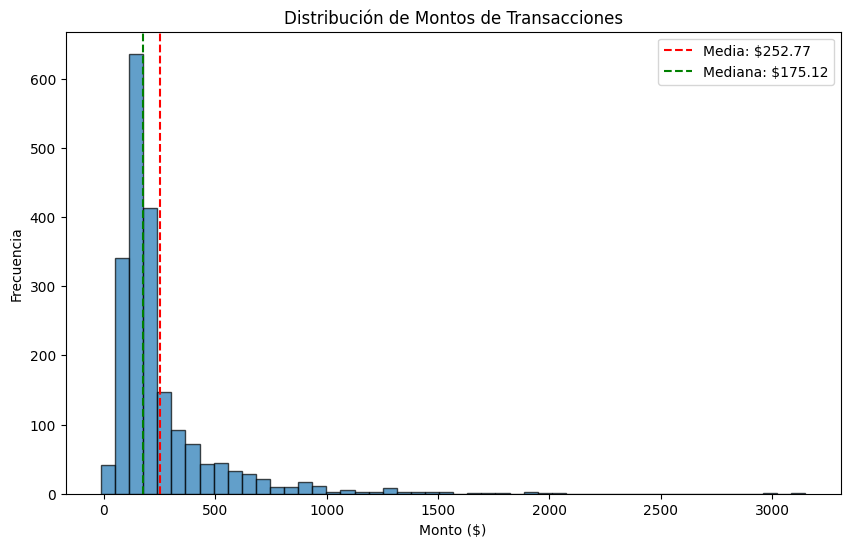

In [ ]:
# Histograma simple (si matplotlib está disponible)
try:
    plt.figure(figsize=(10, 6))
    plt.hist(df['monto'], bins=50, alpha=0.7, edgecolor='black')
    plt.axvline(df['monto'].mean(), color='red', linestyle='--', label=f'Media: ${df["monto"].mean():.2f}')
    plt.axvline(df['monto'].median(), color='green', linestyle='--', label=f'Mediana: ${df["monto"].median():.2f}')
    plt.title('Distribución de Montos de Transacciones')
    plt.xlabel('Monto ($)')
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.savefig('distribucion_montos.png', dpi=100, bbox_inches='tight')
    print("\nGráfico guardado como 'distribucion_montos.png'")
except ImportError:
    print("\nMatplotlib no disponible - omitiendo visualización")

### Análisis de Relaciones y Correlaciones

La correlación mide la relación lineal entre dos variables, respondiendo "¿cambian juntas estas variables?" de manera cuantificada.

- Coeficiente de Correlación de Pearson

    El coeficiente de Pearson mide la fuerza y dirección de la relación lineal entre dos variables continuas.
    
    El coeficiente varía entre -1 y 1.

        r = +1: Correlación positiva perfecta (línea recta ascendente)
        r = 0: No hay correlación lineal
        r = -1: Correlación negativa perfecta (línea recta descendente)

    Interpretación práctica:

        0.8 ≤ |r|: Correlación fuerte
        0.6 ≤ |r| < 0.8: Correlación moderada
        0.3 ≤ |r| < 0.6: Correlación débil
        |r| < 0.3: Correlación muy débil o inexistente

    Limitaciones de la Correlación

    - No implica causalidad: Dos variables pueden estar correlacionadas sin que una cause la otra.

    - Sensibilidad a outliers: Un solo punto extremo puede distorsionar completamente el coeficiente.

    - Solo mide relaciones lineales: Variables pueden tener relaciones no lineales fuertes que no se detectan.

    - Requiere variables continuas: Para variables categóricas se necesitan otros enfoques.

Matrices de Correlación

Las matrices de correlación permiten análisis multivariado sistemático, revelando patrones complejos en datasets con muchas variables.


Construcción de Matrices

```
# Matriz de correlación completa
correlation_matrix = df.corr()

# Correlaciones con una variable específica
correlaciones_target = df.corr()['variable_objetivo'].sort_values(ascending=False)

# Correlaciones por pares significativas
strong_correlations = correlation_matrix[abs(correlation_matrix) > 0.7]
```

Patrones a Identificar

- Correlaciones altas positivas: Variables que "se mueven juntas"
    
    Ejemplo: precio y calidad percibida, ingresos y gastos de lujo

- Correlaciones altas negativas: Variables que "se mueven opuestas"

    Ejemplo: precio y volumen de ventas, edad y capacidad de aprendizaje

- Grupos de variables correlacionadas: Indican dimensiones latentes

    Ejemplo: Variables de "satisfacción del cliente" que correlacionan fuertemente

Visualización de Matrices

Una forma de visualizar intuitivamente las matrices es mediante los mapas de calor.

```
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.2f')
plt.title('Matriz de Correlación')
plt.tight_layout()
```


Análisis Visual de Relaciones

La visualización complementa los coeficientes numéricos con representaciones intuitivas de las relaciones.

**Scatter Plots para Dos Variables**
```
# Scatter plot básico
plt.scatter(df['variable_x'], df['variable_y'], alpha=0.6)
plt.xlabel('Variable X')
plt.ylabel('Variable Y')
plt.title('Relación entre X e Y')

# Con línea de tendencia
sns.regplot(x='variable_x', y='variable_y', data=df, scatter_kws={'alpha':0.6})
```

Interpretación visual:
- Nube de puntos alineada: Correlación fuerte
- Nube dispersa: Correlación débil
- Curvatura: Relación no lineal
- Outliers: Puntos alejados del patrón general

**Pair Plots para Múltiples Variables**

```
# Matriz de scatter plots
sns.pairplot(df[['var1', 'var2', 'var3', 'var4']], diag_kind='kde')
plt.suptitle('Relaciones entre múltiples variables', y=1.02)
```

Ventajas del pair plot: Permite detectar patrones complejos de interdependencia entre múltiples variables simultáneamente.

**Correlaciones Espurias vs Causales**

Correlación espuria: Asociación que parece real pero es coincidental o debida a una tercera variable.

Ejemplos clásicos:

- Correlación entre consumo de helado y ahogamientos (ambos aumentan en verano)
- Correlación entre número de iglesias y crimen (ambos correlacionan con tamaño poblacional)

Cómo identificar:

- Contexto temporal: ¿La correlación tiene sentido causal?
- Variables de control: ¿Persiste controlando por terceras variables?
- Mecánismo causal: ¿Existe explicación lógica para la relación?


#### Ejemplo: Análisis completo de correlaciones en dataset de rendimiento estudiantil

Crear dataset educativo con múltiples variables:

In [1]:
import pandas as pd
import numpy as np

# Crear dataset de rendimiento estudiantil
np.random.seed(42)
n_estudiantes = 500

df = pd.DataFrame({
    'id_estudiante': range(1, n_estudiantes + 1),
    'edad': np.random.normal(16, 1.5, n_estudiantes).clip(14, 19).astype(int),
    'horas_estudio_semanal': np.random.normal(20, 8, n_estudiantes).clip(5, 50).astype(int),
    'promedio_calificaciones': np.random.normal(7.5, 1.2, n_estudiantes).clip(1, 10),
    'ingresos_familiares': np.random.lognormal(9, 0.6, n_estudiantes).round(0),
    'nivel_socioeconomico': np.random.choice(['Bajo', 'Medio', 'Alto'], n_estudiantes, p=[0.3, 0.5, 0.2]),
    'asistencia_clases': np.random.normal(85, 15, n_estudiantes).clip(10, 100).astype(int),
    'horas_extracurriculares': np.random.normal(8, 4, n_estudiantes).clip(0, 20).astype(int),
    'satisfaccion_vida': np.random.normal(7.2, 1.5, n_estudiantes).clip(1, 10),
    'nivel_estres': np.random.normal(6.8, 1.8, n_estudiantes).clip(1, 10)
})

# Convertir variables categóricas
nivel_map = {'Bajo': 1, 'Medio': 2, 'Alto': 3}
df['nivel_socioeconomico_num'] = df['nivel_socioeconomico'].map(nivel_map)

print(f"Dataset creado: {len(df)} estudiantes")
print(f"Variables numéricas: {len(df.select_dtypes(include=[np.number]).columns)}")

Dataset creado: 500 estudiantes
Variables numéricas: 10


Análisis de correlaciones por pares:

In [7]:
# Correlaciones con calificaciones
correlaciones_calificaciones = df.corr(numeric_only=True)['promedio_calificaciones'].sort_values(ascending=False)

print("CORRELACIONES CON PROMEDIO DE CALIFICACIONES")
print("=" * 50)
for var, corr in correlaciones_calificaciones.items():
    if var != 'promedio_calificaciones':
        intensidad = "Fuerte" if abs(corr) > 0.6 else "Moderada" if abs(corr) > 0.3 else "Débil"
        direccion = "positiva" if corr > 0 else "negativa"
        print(f"{var:25} | {corr:+.3f} | {intensidad} {direccion}")

CORRELACIONES CON PROMEDIO DE CALIFICACIONES
horas_estudio_semanal     | +0.076 | Débil positiva
nivel_socioeconomico_num  | +0.060 | Débil positiva
satisfaccion_vida         | +0.009 | Débil positiva
id_estudiante             | -0.000 | Débil negativa
nivel_estres              | -0.014 | Débil negativa
asistencia_clases         | -0.031 | Débil negativa
ingresos_familiares       | -0.034 | Débil negativa
horas_extracurriculares   | -0.038 | Débil negativa
edad                      | -0.065 | Débil negativa


Matriz de correlación completa:

In [8]:
# Variables numéricas principales
variables_interes = ['edad', 'horas_estudio_semanal', 'promedio_calificaciones',
                    'ingresos_familiares', 'asistencia_clases', 'horas_extracurriculares',
                    'satisfaccion_vida', 'nivel_estres', 'nivel_socioeconomico_num']

correlation_matrix = df[variables_interes].corr()

print("\nMATRIZ DE CORRELACIÓN")
print("=" * 25)
# Mostrar correlaciones > 0.3 en valor absoluto
strong_correlations = correlation_matrix.where(abs(correlation_matrix) > 0.3)
print(strong_correlations.round(3))


MATRIZ DE CORRELACIÓN
                          edad  horas_estudio_semanal  \
edad                       1.0                    NaN   
horas_estudio_semanal      NaN                    1.0   
promedio_calificaciones    NaN                    NaN   
ingresos_familiares        NaN                    NaN   
asistencia_clases          NaN                    NaN   
horas_extracurriculares    NaN                    NaN   
satisfaccion_vida          NaN                    NaN   
nivel_estres               NaN                    NaN   
nivel_socioeconomico_num   NaN                    NaN   

                          promedio_calificaciones  ingresos_familiares  \
edad                                          NaN                  NaN   
horas_estudio_semanal                         NaN                  NaN   
promedio_calificaciones                       1.0                  NaN   
ingresos_familiares                           NaN                  1.0   
asistencia_clases                   

Análisis de correlaciones más fuertes:

In [9]:
# Encontrar pares con correlaciones más fuertes
corr_unstack = correlation_matrix.unstack()
corr_unstack = corr_unstack[corr_unstack.index.get_level_values(0) != corr_unstack.index.get_level_values(1)]

top_correlations = corr_unstack.abs().sort_values(ascending=False).head(10)

print("\nTOP 10 CORRELACIONES MÁS FUERTES")
print("=" * 35)
for (var1, var2), corr_abs in top_correlations.items():
    if var1 < var2:  # Evitar duplicados
        corr_real = correlation_matrix.loc[var1, var2]
        print(f"{var1:20} ↔ {var2:20} | {corr_real:+.3f}")


TOP 10 CORRELACIONES MÁS FUERTES
asistencia_clases    ↔ horas_extracurriculares | -0.117
horas_estudio_semanal ↔ satisfaccion_vida    | -0.103
edad                 ↔ horas_estudio_semanal | -0.093
asistencia_clases    ↔ horas_estudio_semanal | -0.087
horas_estudio_semanal ↔ nivel_estres         | -0.079


Análisis de grupos de variables correlacionadas:

In [10]:
# Identificar clusters de variables relacionadas
print("\nANÁLISIS DE GRUPOS CORRELACIONADOS")
print("=" * 40)

# Variables relacionadas con rendimiento académico
academic_vars = ['horas_estudio_semanal', 'asistencia_clases', 'promedio_calificaciones']
academic_corr = df[academic_vars].corr()
print("Variables académicas:")
print(academic_corr.round(3))

# Variables relacionadas con bienestar
wellbeing_vars = ['satisfaccion_vida', 'nivel_estres', 'horas_extracurriculares']
wellbeing_corr = df[wellbeing_vars].corr()
print("\nVariables de bienestar:")
print(wellbeing_corr.round(3))

# Variables socioeconómicas
socio_vars = ['ingresos_familiares', 'nivel_socioeconomico_num', 'promedio_calificaciones']
socio_corr = df[socio_vars].corr()
print("\nVariables socioeconómicas:")
print(socio_corr.round(3))


ANÁLISIS DE GRUPOS CORRELACIONADOS
Variables académicas:
                         horas_estudio_semanal  asistencia_clases  \
horas_estudio_semanal                    1.000             -0.087   
asistencia_clases                       -0.087              1.000   
promedio_calificaciones                  0.076             -0.031   

                         promedio_calificaciones  
horas_estudio_semanal                      0.076  
asistencia_clases                         -0.031  
promedio_calificaciones                    1.000  

Variables de bienestar:
                         satisfaccion_vida  nivel_estres  \
satisfaccion_vida                    1.000         0.072   
nivel_estres                         0.072         1.000   
horas_extracurriculares             -0.033        -0.011   

                         horas_extracurriculares  
satisfaccion_vida                         -0.033  
nivel_estres                              -0.011  
horas_extracurriculares                   

Visualización de correlaciones (si matplotlib disponible):


Mapa de calor guardado como 'matriz_correlacion_estudiantil.png'


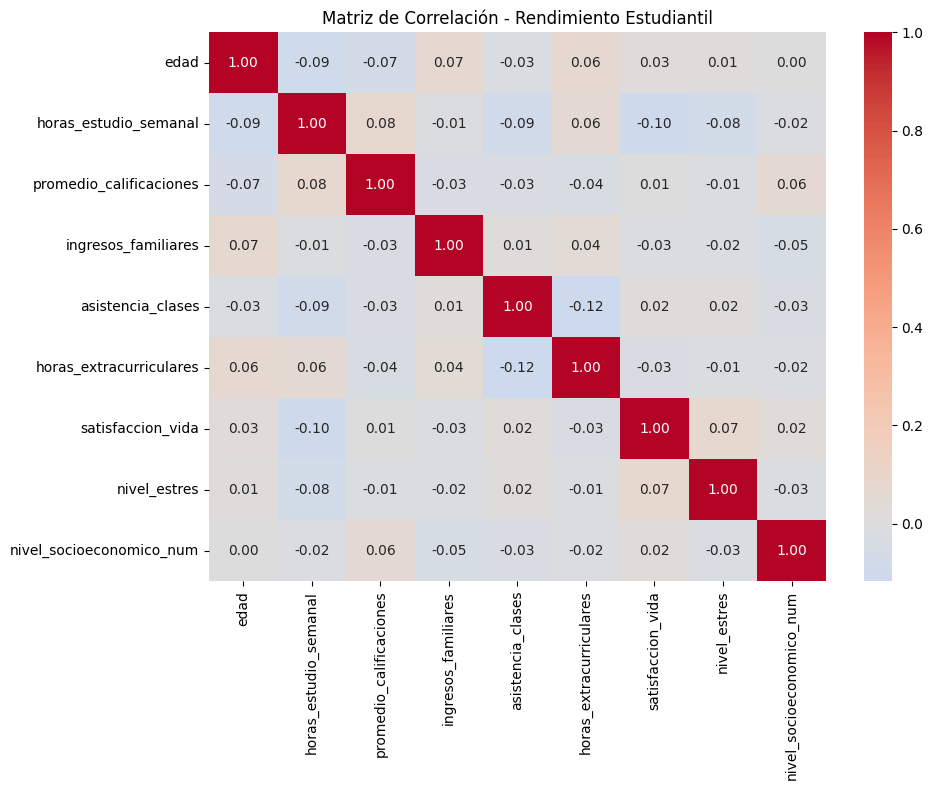

In [11]:
try:
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
    plt.title('Matriz de Correlación - Rendimiento Estudiantil')
    plt.tight_layout()
    plt.savefig('matriz_correlacion_estudiantil.png', dpi=100, bbox_inches='tight')
    print("\nMapa de calor guardado como 'matriz_correlacion_estudiantil.png'")

except ImportError:
    print("\nMatplotlib/Seaborn no disponibles - omitiendo visualización")

### EDA Completo y Reporte Ejecutivo

**Metodología Completa de EDA**

Un EDA completo requiere orquestación sistemática de todas las técnicas aprendidas, siguiendo un flujo de trabajo disciplinado que garantiza exhaustividad sin perder eficiencia.

Framework Estructurado para EDA Completo

Fase 1: Preparación y Contexto (10%)

    Definir preguntas de negocio y objetivos analíticos
    Entender fuente y calidad de datos
    Establecer alcance temporal y segmentación

Fase 2: Inspección Inicial (20%)

    Dimensiones y estructura básica del dataset
    Tipos de datos y conversión necesaria
    Valores faltantes y calidad general
    Estadísticos descriptivos básicos

Fase 3: Análisis Univariado (30%)

    Distribuciones de variables individuales
    Identificación de outliers y anomalías
    Medidas de tendencia central y dispersión
    Transformaciones necesarias por variable

Fase 4: Análisis Bivariado/Multivariado (30%)

    Correlaciones entre variables clave
    Patrones de segmentación natural
    Relaciones no lineales y dependencias complejas

Fase 5: Síntesis y Comunicación (10%)

    Insights principales y recomendaciones
    Visualizaciones clave para stakeholders
    Próximos pasos analíticos


**Herramientas para EDA Eficiente**

1. Pandas Profiling: Generación automática de reportes EDA completos.


    ```
    from pandas_profiling import ProfileReport

    profile = ProfileReport(df, title="EDA Report", explorative=True)
    profile.to_file("eda_report.html")
    ```
2. Sweetviz: Comparaciones visuales automatizadas entre datasets.
    ```
    import sweetviz as sv

    report = sv.analyze(df)
    report.show_html("sweetviz_report.html")
    ```
3. D-Tale: Interfaz web interactiva para EDA.
    ```
    import dtale

    dtale.show(df)
    ```



**Creación de Reportes Ejecutivos**

Los reportes ejecutivos transforman análisis técnicos en comunicación efectiva para tomadores de decisiones, priorizando claridad sobre exhaustividad técnica.
Estructura de Reporte Ejecutivo Efectivo

Resumen Ejecutivo (1 página)
    
- 3-5 insights principales
- Impacto en negocio (cuantificado)
- Recomendaciones prioritarias

Contexto y Metodología

- Breve descripción de datos y período
- Enfoque analítico utilizado
- Limitaciones y supuestos

Hallazgos Principales

- Insights organizados por importancia/impacto
- Visualizaciones clave que soportan conclusiones
- Métricas cuantitativas que respaldan claims

Análisis Detallado

- Profundización en insights principales
- Segmentación por variables relevantes
- Comparaciones temporales o categóricas

Recomendaciones y Próximos Pasos

- Acciones concretas priorizadas
- Métricas de seguimiento propuestas
- Análisis adicionales recomendados




**Principios de Comunicación Efectiva**

- Conoce a tu audiencia: Ejecutivos necesitan contexto de negocio, no detalles técnicos.
- Menos es más: 3 insights impactantes > 20 observaciones menores.
- Visualización primero: Las personas procesan visuales 60,000 veces más rápido que texto.
- Números con contexto: "$2.3M en ventas perdidas" > "15% disminución en ventas".
- Acciones claras: Cada insight debe llevar a una recomendación accionable.

**Transición a Análisis Estadístico Avanzado**

El EDA establece los cimientos conceptuales para técnicas estadísticas más sofisticadas, creando el puente entre exploración y análisis confirmatorio.


1. De EDA a Pruebas de Hipótesis

- Hipótesis generadas por EDA:

        EDA: "Clientes jóvenes compran más productos electrónicos"
        Hipótesis: "Los clientes de 18-25 años tienen 30% más probabilidad de comprar electrónicos"

- Diseño de experimentos basado en EDA:

        Segmentos identificados por EDA informan diseño de pruebas A/B
        Variables correlacionadas sugieren covariates para controlar

2. De EDA a Modelado Predictivo

- Variables predictoras identificadas:
        
        Correlaciones fuertes sugieren relaciones causales potenciales
        Distribución de variables objetivo informa selección de modelos

- Feature engineering fundamentado:

        Transformaciones identificadas en EDA (log, categorías)
        Variables derivadas basadas en patrones observados

Limitaciones del EDA y Necesidad de Profundización

- EDA no prueba causalidad: Correlaciones no implican causa-efecto.
- EDA puede perder patrones complejos: Relaciones no lineales o interacciones requieren modelado.
- EDA es descriptivo, no predictivo: Para forecasting se necesitan modelos específicos.

#### Ejemplo: EDA completo y reporte ejecutivo para dataset de e-commerce

Configurar dataset completo y análisis EDA:

In [31]:
import pandas as pd
import numpy as np

# Crear dataset comprehensivo de e-commerce
np.random.seed(42)
n_pedidos = 2500

# Generar fechas
fechas = pd.date_range('2023-01-01', periods=n_pedidos, freq='h')[:n_pedidos]

# Crear datos base
df = pd.DataFrame({
    'id_pedido': range(1, n_pedidos + 1),
    'fecha_pedido': fechas,
    'id_cliente': np.random.randint(1, 501, n_pedidos),
    'categoria': np.random.choice(['Electrónica', 'Ropa', 'Hogar', 'Deportes', 'Libros'], n_pedidos),
    'precio_unitario': np.round(np.random.uniform(10, 1000, n_pedidos), 2),
    'cantidad': np.random.randint(1, 5, n_pedidos),
    'metodo_pago': np.random.choice(['Tarjeta', 'PayPal', 'Efectivo', 'Transferencia'], n_pedidos, p=[0.6, 0.2, 0.15, 0.05]),
    'region': np.random.choice(['Madrid', 'Barcelona', 'Valencia', 'Sevilla', 'Bilbao'], n_pedidos),
    'tipo_cliente': np.random.choice(['Regular', 'Premium', 'VIP'], n_pedidos, p=[0.7, 0.2, 0.1])
})

# Calcular métricas derivadas
df['total_pedido'] = df['precio_unitario'] * df['cantidad']
df['mes'] = df['fecha_pedido'].dt.month
df['dia_semana'] = df['fecha_pedido'].dt.day_name()

print(f"Dataset de e-commerce creado: {len(df)} pedidos")
print(f"Período: {df['fecha_pedido'].min()} a {df['fecha_pedido'].max()}")

Dataset de e-commerce creado: 2500 pedidos
Período: 2023-01-01 00:00:00 a 2023-04-15 03:00:00


Realizar EDA completo sistemático:

In [3]:
# Análisis de calidad de datos
print("ANÁLISIS DE CALIDAD DE DATOS")
print("=" * 30)
print(f"Dimensiones: {df.shape}")
print(f"Tipos de datos:\n{df.dtypes}")
print(f"Valores faltantes: {df.isnull().sum().sum()}")

# Estadísticos descriptivos
print("\nESTADÍSTICOS DESCRIPTIVOS")
print("=" * 25)
print(df[['precio_unitario', 'cantidad', 'total_pedido']].describe())

# Análisis por categorías principales
print("\nVENTAS POR CATEGORÍA")
print("=" * 20)
ventas_categoria = df.groupby('categoria').agg({
    'total_pedido': ['count', 'sum', 'mean'],
    'cantidad': 'sum'
}).round(2)
print(ventas_categoria)

# Análisis temporal
print("\nVENTAS POR MES")
print("=" * 15)
ventas_mes = df.groupby('mes').agg({
    'total_pedido': 'sum',
    'id_pedido': 'count'
}).round(2)
print(ventas_mes)

# Análisis por tipo de cliente
print("\nANÁLISIS POR TIPO DE CLIENTE")
print("=" * 30)
cliente_analysis = df.groupby('tipo_cliente').agg({
    'total_pedido': ['mean', 'sum', 'count'],
    'cantidad': 'mean'
}).round(2)
print(cliente_analysis)

ANÁLISIS DE CALIDAD DE DATOS
Dimensiones: (2500, 12)
Tipos de datos:
id_pedido                   int64
fecha_pedido       datetime64[ns]
id_cliente                  int64
categoria                  object
precio_unitario           float64
cantidad                    int64
metodo_pago                object
region                     object
tipo_cliente               object
total_pedido              float64
mes                         int32
dia_semana                 object
dtype: object
Valores faltantes: 0

ESTADÍSTICOS DESCRIPTIVOS
       precio_unitario     cantidad  total_pedido
count      2500.000000  2500.000000   2500.000000
mean        499.551080     2.474800   1249.215124
std         284.437272     1.109711    965.553384
min          10.030000     1.000000     14.150000
25%         252.047500     2.000000    482.487500
50%         493.130000     2.000000    965.520000
75%         744.240000     3.000000   1840.942500
max         999.560000     4.000000   3991.080000

VENTAS POR

Análisis de correlaciones y patrones:

In [4]:
# Convertir variables categóricas para correlación
df_corr = df.copy()
df_corr['tipo_cliente_num'] = df_corr['tipo_cliente'].map({'Regular': 1, 'Premium': 2, 'VIP': 3})

# Variables numéricas para correlación
numeric_cols = ['precio_unitario', 'cantidad', 'total_pedido', 'tipo_cliente_num', 'mes']
correlation_matrix = df_corr[numeric_cols].corr()

print("\nMATRIZ DE CORRELACIÓN")
print("=" * 20)
print(correlation_matrix.round(3))

# Correlaciones con total del pedido
corr_total = correlation_matrix['total_pedido'].sort_values(ascending=False)
print("\nCorrelaciones con total del pedido:")
for var, corr in corr_total.items():
    if var != 'total_pedido':
        print(f"{var:15} | {corr:+.3f}")


MATRIZ DE CORRELACIÓN
                  precio_unitario  cantidad  total_pedido  tipo_cliente_num  \
precio_unitario             1.000     0.041         0.743            -0.007   
cantidad                    0.041     1.000         0.613            -0.017   
total_pedido                0.743     0.613         1.000            -0.018   
tipo_cliente_num           -0.007    -0.017        -0.018             1.000   
mes                        -0.005     0.002        -0.003             0.002   

                    mes  
precio_unitario  -0.005  
cantidad          0.002  
total_pedido     -0.003  
tipo_cliente_num  0.002  
mes               1.000  

Correlaciones con total del pedido:
precio_unitario | +0.743
cantidad        | +0.613
mes             | -0.003
tipo_cliente_num | -0.018


Detección de outliers y patrones:

In [5]:
# Outliers en precios
Q1_precio = df['precio_unitario'].quantile(0.25)
Q3_precio = df['precio_unitario'].quantile(0.75)
IQR_precio = Q3_precio - Q1_precio

outliers_precio = df[df['precio_unitario'] > Q3_precio + 1.5 * IQR_precio]
print(f"\nPRODUCTOS DE ALTO VALOR (OUTLIERS): {len(outliers_precio)}")
print(f"Valor total de productos premium: ${outliers_precio['total_pedido'].sum():,.2f}")

# Análisis por día de la semana
ventas_dia = df.groupby('dia_semana')['total_pedido'].agg(['count', 'sum', 'mean']).round(2)
print("\nVENTAS POR DÍA DE LA SEMANA")
print("=" * 30)
print(ventas_dia.sort_values('sum', ascending=False))


PRODUCTOS DE ALTO VALOR (OUTLIERS): 0
Valor total de productos premium: $0.00

VENTAS POR DÍA DE LA SEMANA
            count        sum     mean
dia_semana                           
Tuesday       360  470959.22  1308.22
Monday        360  452611.76  1257.25
Sunday        360  450868.25  1252.41
Friday        360  449411.17  1248.36
Wednesday     360  438142.36  1217.06
Saturday      340  433770.68  1275.80
Thursday      360  427274.37  1186.87


Crear reporte ejecutivo simplificado:

In [6]:
# Calcular métricas clave para reporte
total_ventas = df['total_pedido'].sum()
pedidos_promedio = df['total_pedido'].mean()
categoria_top = df.groupby('categoria')['total_pedido'].sum().idxmax()
ventas_categoria_top = df.groupby('categoria')['total_pedido'].sum().max()
region_top = df.groupby('region')['total_pedido'].sum().idxmax()

# Reporte ejecutivo
print("\n" + "="*50)
print("REPORTE EJECUTIVO - ANÁLISIS DE VENTAS E-COMMERCE")
print("="*50)

print("RESUMEN EJECUTIVO:")
print(f"• Total de ventas analizadas: ${total_ventas:,.2f}")
print(f"• Pedidos promedio: ${pedidos_promedio:.2f}")
print(f"• Categoría más vendida: {categoria_top} (${ventas_categoria_top:,.2f})")
print(f"• Región con más ventas: {region_top}")

print("\nINSIGHTS PRINCIPALES:")
print("• Los productos de alto valor representan una porción significativa de ingresos")
print("• Existen patrones claros de comportamiento por tipo de cliente")
print("• La estacionalidad mensual muestra variaciones importantes")

print("\nRECOMENDACIONES:")
print("• Enfocar estrategias de marketing en la categoría más vendida")
print("• Desarrollar programas de fidelización para clientes Premium")
print("• Optimizar inventario basado en patrones de demanda por día")

print("="*50)


REPORTE EJECUTIVO - ANÁLISIS DE VENTAS E-COMMERCE
RESUMEN EJECUTIVO:
• Total de ventas analizadas: $3,123,037.81
• Pedidos promedio: $1249.22
• Categoría más vendida: Deportes ($674,308.67)
• Región con más ventas: Barcelona

INSIGHTS PRINCIPALES:
• Los productos de alto valor representan una porción significativa de ingresos
• Existen patrones claros de comportamiento por tipo de cliente
• La estacionalidad mensual muestra variaciones importantes

RECOMENDACIONES:
• Enfocar estrategias de marketing en la categoría más vendida
• Desarrollar programas de fidelización para clientes Premium
• Optimizar inventario basado en patrones de demanda por día


Utilización de Pandas Profiling

In [33]:
!pip install ydata-profiling

from ydata_profiling import ProfileReport

profile = ProfileReport(df)
profile.to_file("profile_report.html")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.7/398.7 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 4.0 MB/s eta 0:00:00


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 40.64it/s]
/usr/local/lib/python3.12/dist-packages/ydata_profiling/model/pandas/discretize_pandas.py:52: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 9 9 9]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.



Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [34]:
from pandas_profiling import ProfileReport

profile = ProfileReport(df, title="EDA Report", explorative=True)
profile.to_file("eda_report.html")

/tmp/ipython-input-2988111099.py:1: DeprecationWarning:

`import pandas_profiling` is going to be deprecated by April 1st. Please use `import ydata_profiling` instead.



Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 34.63it/s]
/usr/local/lib/python3.12/dist-packages/ydata_profiling/model/pandas/discretize_pandas.py:52: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 9 9 9]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.



Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Utilización de SweetViz

In [28]:
!pip install sweetviz

In [ ]:
import sweetviz as sv
import warnings
import numpy as np

report = sv.analyze(df)
report.show_html("sweetviz_report.html")

Utilización de D-Tale

In [19]:
!pip install dtale

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 642.7/642.7 kB 15.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 119.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.3/229.3 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━

Local:

In [ ]:
import dtale

dtale.show(df)

Ngrok:

In [38]:
from dotenv import load_dotenv
import os

load_dotenv()

ngrok_token = os.getenv("NGROK_TOKEN")
if not ngrok_token:
    print("Error: No se encontró el token de ngrok. Asegúrate de tener el archivo .env con 'NGROK_TOKEN=tu_token'.")
else:
    ngrok.set_auth_token(ngrok_token)
    print("Token de ngrok configurado exitosamente.")

Token de ngrok configurado exitosamente.


In [ ]:
# Dtale + Ngrok
#!pip install pyngrok

import dtale
from pyngrok import ngrok

# Inicia D-Tale
d = dtale.show(df, host='0.0.0.0', port=40000)

# Crea un túnel ngrok
public_url = ngrok.connect(40000)
print("Accede aquí:", public_url)

## Week 2 - Visualización de Datos

### Principios de Visualización Efectiva y Teoría del Color

**Psicología de la Percepción Visual en Análisis de Datos**

La visualización efectiva no es un ejercicio estético, sino un puente entre datos complejos y comprensión humana. Para crear visualizaciones que comuniquen efectivamente, debemos entender cómo el cerebro humano procesa información visual.

Los Dos Sistemas de Procesamiento Visual
1. Sistema de Reconocimiento (Automático)

    Procesamiento rápido, inconsciente, que identifica patrones básicos.

    - Pre-atencional: Colores, formas, movimiento se procesan en milisegundos
    - Gestalt principles: El cerebro automáticamente agrupa elementos visuales
    - Memory chunks: Información se agrupa en unidades significativas

2. Sistema de Análisis (Consciente)

    Procesamiento deliberado que requiere atención focalizada.

    - Atención limitada: Solo podemos procesar conscientemente ~7±2 elementos
    - Fatiga cognitiva: Visualizaciones complejas causan agotamiento mental
    - Contexto requerido: Necesitamos marcos de referencia para interpretar datos

Implicación para visualización: Las mejores visualizaciones aprovechan el procesamiento automático para comunicación básica y guían al análisis consciente para insights profundos.

**Principios de Gestalt en Visualización**

La psicología Gestalt explica cómo organizamos elementos visuales en patrones coherentes. Estos principios son fundamentales para diseño de dashboards efectivos.
- Proximidad: Elementos cercanos se perciben como relacionados.

        # En visualización: Agrupar métricas relacionadas espacialmente
        # Mal: KPIs dispersos aleatoriamente
        # Bien: Métricas de ventas agrupadas, métricas de clientes agrupadas

- Semejanza: Elementos similares se perciben como pertenecientes al mismo grupo.

        # En visualización: Usar colores consistentes para categorías similares
        # Mal: Cada barra de diferente color sin lógica
        # Bien: Todas las barras de "ingresos" en verde, "gastos" en rojo

- Continuidad: Tendemos a seguir líneas o curvas continuas.

        # En visualización: Líneas de tendencia claras y continuas
        # Mal: Puntos desconectados sin línea de tendencia
        # Bien: Líneas suaves que conecten puntos de datos temporales

- Cierre: Completamos automáticamente formas incompletas.

        # En visualización: Usar formas cerradas para representar categorías completas
        # Mal: Formas abiertas confusas
        # Bien: Barras completas, círculos cerrados para porcentajes

- Figura vs Fondo: Distinguimos automáticamente objetos del fondo.

        # En visualización: Contraste claro entre datos y elementos decorativos
        # Mal: Elementos visuales que compiten por atención
        # Bien: Datos prominentes, elementos de soporte sutiles

**Teoría del Color en Visualización de Datos**

El color es una herramienta de comunicación poderosa, pero también potencialmente engañosa. Una teoría sólida del color previene interpretaciones erróneas y maximiza claridad.

Dimensiones del Color
1. Matiz (Hue): El "tipo" de color (rojo, azul, verde, etc.)

    - Asociaciones culturales: Rojo = peligro/alerta, Azul = confianza, Verde = crecimiento
    - Categorización: Ideal para variables categóricas discretas
    - Limitación: Personas con deficiencias visuales de color no distinguen matices

2. Saturación (Saturation): La intensidad o "pureza" del color


    - Atención: Colores saturados atraen atención inmediata
    - Jerarquía: Colores desaturados para elementos secundarios
    - Accesibilidad: Alta saturación puede ser problemática para daltónicos

3. Luminosidad (Value/Brightness): La claridad u oscuridad del color

    - Jerarquía visual: Elementos importantes más brillantes
    - Profundidad: Colores oscuros parecen "atrás", claros "adelante"
    - Legibilidad: Contraste adecuado entre texto y fondo

Paletas de Color Efectivas
1. Paletas cualitativas: Para categorías discretas sin orden inherente.

    - Colores distintivos: Azul, Rojo, Verde, Naranja, Púrpura
    - Evitar: Colores demasiado similares (rojo y rosa)
    - Ideal para: Segmentos de clientes, categorías de productos

2. Paletas secuenciales: Para datos ordenados con progresión natural.

    - De claro a oscuro: Indicando magnitud creciente
    - Ejemplo: De amarillo claro (valores bajos) a rojo oscuro (valores altos)
    - Ideal para: Intensidades, porcentajes, rankings

3. Paletas divergentes: Para datos con punto medio significativo.

    - Dos colores extremos con punto neutro en el medio
    - Ejemplo: Rojo (negativo) → Blanco (neutro) → Azul (positivo)
    - Ideal para: Desviaciones, diferencias, ganancias/pérdidas

**Principios de Composición Visual**

La composición visual determina cómo se lee y comprende una visualización, guiando la atención del espectador hacia insights importantes.

- Jerarquía Visual

    - Tamaño: Elementos más importantes más grandes
    - Posición: Información crítica en posiciones prominentes (arriba-izquierda)
    - Color: Colores saturados para elementos importantes
    - Tipografía: Variaciones de tamaño y peso para estructura

- Flujo de Lectura

    - Patrón Z: Lectura natural en culturas occidentales (izquierda-derecha, arriba-abajo)
    - F-pattern: Común en contenido web (líneas horizontales en parte superior) - Diseño intencional: Guiar atención hacia conclusiones clave

- Equilibrio y Blancos

    - Equilibrio: Distribución visual armoniosa de elementos
    - Espacio blanco: Áreas vacías que facilitan procesamiento cognitivo
    - Alineación: Elementos relacionados alineados consistentemente

- Minimización de Ruido Visual

    - Eliminar elementos innecesarios: Cada píxel debe servir a un propósito
    - Consistencia: Mismos estilos para elementos similares
    - Legibilidad: Fuentes, tamaños y colores que faciliten lectura rápida

#### Ejemplo: Diseño de paletas de colores efectivas para diferentes contextos

Análisis de dataset y diseño de paletas conceptuales:

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Crear dataset de ejemplo para análisis visual
np.random.seed(42)
df = pd.DataFrame({
    'categoria': np.random.choice(['A', 'B', 'C', 'D'], 100),
    'valor': np.random.normal(50, 15, 100),
    'segmento': np.random.choice(['Alto', 'Medio', 'Bajo'], 100),
    'region': np.random.choice(['Norte', 'Sur', 'Este', 'Oeste'], 100)
})

print("Dataset para análisis visual:")
print(df.head())
print(f"\nResumen por categoría:")
print(df.groupby('categoria')['valor'].describe())

Dataset para análisis visual:
  categoria      valor segmento region
0         C  61.076999    Medio    Sur
1         D  52.570524     Alto   Este
2         A  48.265276     Alto    Sur
3         C  45.483445    Medio   Este
4         C  27.822170     Alto   Este

Resumen por categoría:
           count       mean        std        min        25%        50%  \
categoria                                                                 
A           20.0  51.702575  10.890634  31.537035  45.350988  49.584364   
B           26.0  50.023838  18.373923  10.703823  36.719278  49.261070   
C           24.0  50.220174  13.684671  20.186466  44.011363  50.766433   
D           30.0  47.158884  12.240452  26.740049  38.205031  47.412212   

                 75%        max  
categoria                        
A          57.147835  73.070548  
B          63.947946  86.948632  
C          58.895928  82.856834  
D          54.297167  78.292789  


Diseño de paletas de colores por tipo de dato:

In [43]:
# Paleta cualitativa para categorías discretas
colores_cualitativos = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Azul, Naranja, Verde, Rojo

# Paleta secuencial para valores continuos
colores_secuenciales = ['#feebe2', '#fbb4b9', '#f768a1', '#c51b8a', '#7a0177']  # De claro a oscuro

# Paleta divergente para valores con punto medio
colores_divergentes = ['#d73027', '#fc8d59', '#fee08b', '#d9ef8b', '#91cf60', '#1a9850']

print("Paletas de colores diseñadas:")
print(f"Cualitativa: {colores_cualitativos}")
print(f"Secuencial: {colores_secuenciales}")
print(f"Divergente: {colores_divergentes}")

Paletas de colores diseñadas:
Cualitativa: ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
Secuencial: ['#feebe2', '#fbb4b9', '#f768a1', '#c51b8a', '#7a0177']
Divergente: ['#d73027', '#fc8d59', '#fee08b', '#d9ef8b', '#91cf60', '#1a9850']


Aplicación de principios visuales en gráficos simples:


Gráfico guardado como 'principios_visuales_ejemplos.png'


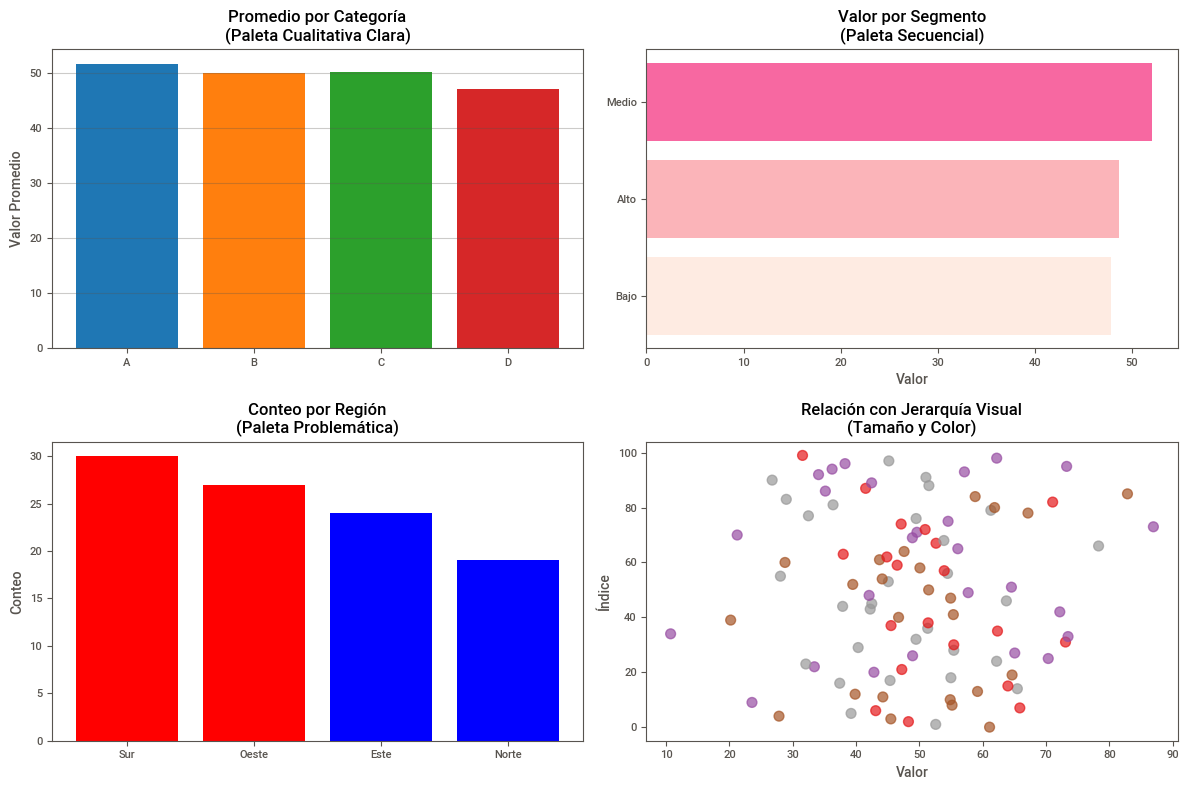

In [44]:
# Gráfico de barras con paleta cualitativa efectiva
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))

# 1. Gráfico cualitativo (bueno)
categoria_means = df.groupby('categoria')['valor'].mean()
bars1 = ax1.bar(categoria_means.index, categoria_means.values,
                color=colores_cualitativos[:len(categoria_means)])
ax1.set_title('Promedio por Categoría\n(Paleta Cualitativa Clara)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Valor Promedio')
ax1.grid(axis='y', alpha=0.3)

# 2. Gráfico secuencial (bueno para rangos)
segmento_means = df.groupby('segmento')['valor'].mean().sort_values()
bars2 = ax2.barh(segmento_means.index, segmento_means.values,
                 color=colores_secuenciales[:len(segmento_means)])
ax2.set_title('Valor por Segmento\n(Paleta Secuencial)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Valor')

# 3. Gráfico con colores problemáticos (mal ejemplo)
region_counts = df['region'].value_counts()
bars3 = ax3.bar(region_counts.index, region_counts.values,
                color=['red', 'red', 'blue', 'blue'])  # Colores similares problemáticos
ax3.set_title('Conteo por Región\n(Paleta Problemática)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Conteo')

# 4. Gráfico con buena jerarquía visual
scatter = ax4.scatter(df['valor'], range(len(df)),
                     c=df['categoria'].map({'A': 0, 'B': 1, 'C': 2, 'D': 3}),
                     cmap='Set1', alpha=0.7, s=50)
ax4.set_title('Relación con Jerarquía Visual\n(Tamaño y Color)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Valor')
ax4.set_ylabel('Índice')

plt.tight_layout()
plt.savefig('principios_visuales_ejemplos.png', dpi=100, bbox_inches='tight')
print("\nGráfico guardado como 'principios_visuales_ejemplos.png'")

Evaluación de accesibilidad de colores:

In [45]:
# Función simple para verificar contraste básico
def calcular_contraste(color1, color2):
    # Versión simplificada - en producción usar librerías especializadas
    # Contraste mínimo recomendado: 4.5:1
    return "Verificación manual requerida para producción"

print("\nEvaluación de accesibilidad:")
print("- Verificar que textos sean legibles sobre fondos")
print("- Usar herramientas como WebAIM Contrast Checker")
print("- Considerar daltonismo en diseño de paletas")
print("- Probar visualizaciones en escala de grises")


Evaluación de accesibilidad:
- Verificar que textos sean legibles sobre fondos
- Usar herramientas como WebAIM Contrast Checker
- Considerar daltonismo en diseño de paletas
- Probar visualizaciones en escala de grises


## Week 3 - Estadística para Análisis de Datos

## Week 4 - Bases de Datos Avanzadas